# Trabalho - Bases Engenharia de Software VI - Inteligência Artificial - Seção I - Análise Exploratória de Dados
Professor: Marcio Andrey Roselli  
Estudante: Bianco Da Costa Oliveira

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

#Configuração de Hardware
device = torch.device("mps" if torch.backends.mps.is_available() else 
                     "cuda" if torch.cuda.is_available() else "cpu")

print(f"Executando em: {device}")

#Download do dataset 
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
try:
    df = pd.read_csv(url, sep=";")
    print(f"Dataset carregado com sucesso! Dimensões: {df.shape}")
except Exception as e:
    print(f"Erro ao carregar dados: {e}")

df.head()

Executando em: mps
Dataset carregado com sucesso! Dimensões: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


--- Verificação de Valores Ausentes ---
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Conclusão: O dataset não possui valores nulos.

--- Estatísticas Descritivas dos 11 atributos ---


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


/var/folders/gm/jwfmlvvn12d2lfg_vnjbf0dm0000gn/T/ipykernel_16099/3646335897.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality', ax=axes[0], palette='viridis')
/var/folders/gm/jwfmlvvn12d2lfg_vnjbf0dm0000gn/T/ipykernel_16099/3646335897.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='alvo', ax=axes[1], palette='coolwarm')
/var/folders/gm/jwfmlvvn12d2lfg_vnjbf0dm0000gn/T/ipykernel_16099/3646335897.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='sulphates', x='alvo', ax=axes[2], palett

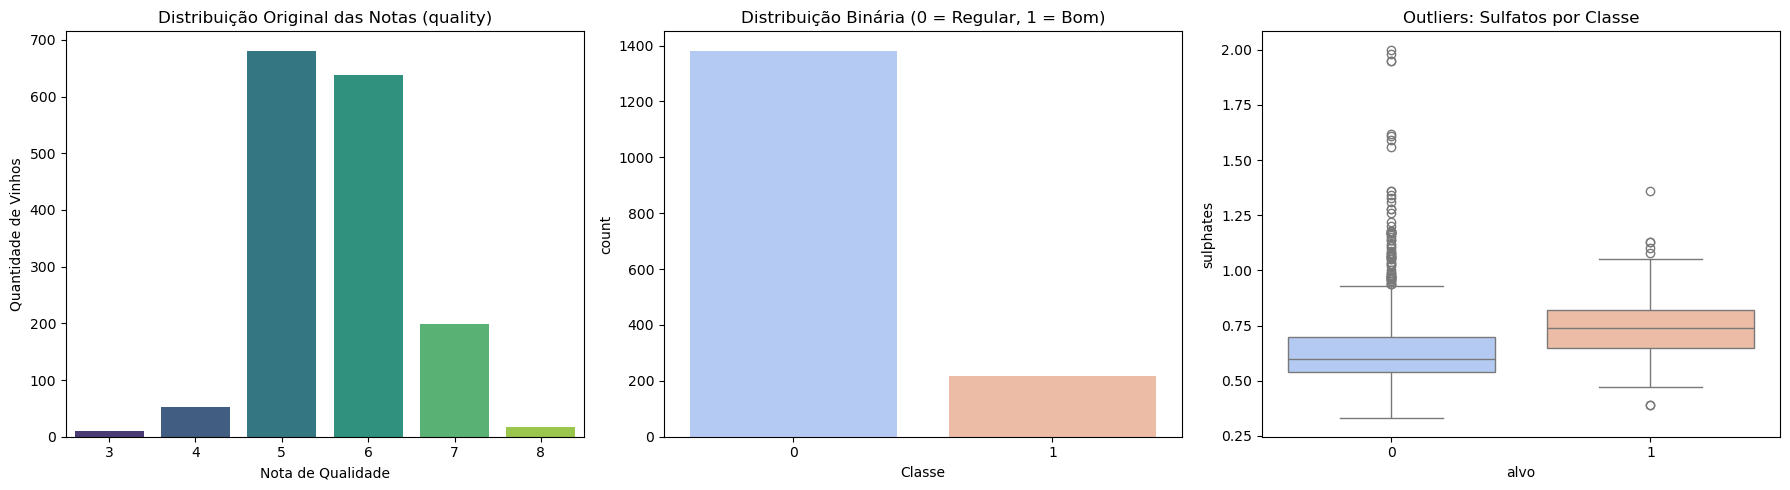

--- Correlação dos atributos com a classe 'Bom' (alvo) ---


/var/folders/gm/jwfmlvvn12d2lfg_vnjbf0dm0000gn/T/ipykernel_16099/3646335897.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlacoes.values, y=correlacoes.index, palette='RdBu_r', ax=ax_corr)


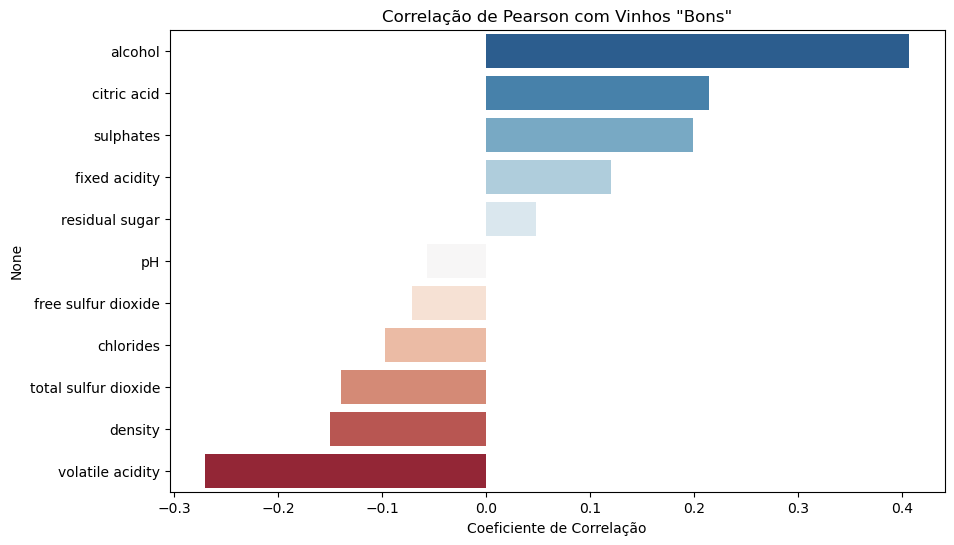

In [3]:
print("--- Verificação de Valores Ausentes ---")
print(df.isnull().sum())
print("\nConclusão: O dataset não possui valores nulos.\n")

print("--- Estatísticas Descritivas dos 11 atributos ---")
display(df.drop(columns=['quality']).describe().T)

# Vinho "bom" (quality >= 7) vs. "regular" (quality < 7)
df["alvo"] = (df["quality"] >= 7).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='quality', ax=axes[0], palette='viridis')
axes[0].set_title('Distribuição Original das Notas (quality)')
axes[0].set_xlabel('Nota de Qualidade')
axes[0].set_ylabel('Quantidade de Vinhos')

sns.countplot(data=df, x='alvo', ax=axes[1], palette='coolwarm')
axes[1].set_title('Distribuição Binária (0 = Regular, 1 = Bom)')
axes[1].set_xlabel('Classe')

sns.boxplot(data=df, y='sulphates', x='alvo', ax=axes[2], palette='coolwarm')
axes[2].set_title('Outliers: Sulfatos por Classe')

plt.tight_layout()
plt.show()

print("--- Correlação dos atributos com a classe 'Bom' (alvo) ---")
correlacoes = df.corr()['alvo'].drop(['quality', 'alvo']).sort_values(ascending=False)

fig_corr, ax_corr = plt.subplots(figsize=(10, 6))
sns.barplot(x=correlacoes.values, y=correlacoes.index, palette='RdBu_r', ax=ax_corr)
ax_corr.set_title('Correlação de Pearson com Vinhos "Bons"')
ax_corr.set_xlabel('Coeficiente de Correlação')
plt.show()